<a href="https://colab.research.google.com/github/rudrarathore169/data-engineering/blob/main/Projects/The%20Business%20Impact%20of%20AI%20Adoption/ai_impact_on_businesses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Adoption & Business Performance Analysis


### 1. Analyze the AI adoption dataset to evaluate trends and their influence on business performance across various industries and countries during the period 2015–2025.

### 2. Perform data cleaning and preprocessing by validating data quality, checking duplicates and data types, renaming columns for better readability, and detecting outliers using statistical and visualization techniques.

### 3. Conduct Exploratory Data Analysis (EDA) using NumPy, Pandas, Matplotlib, and Seaborn to identify trends, correlations, and business insights related to AI adoption, investment, productivity, revenue impact, and automation across industries and countries.

### 4. Evaluate how AI adoption varies across industries, countries, and time, and analyze its impact on productivity, revenue, cost savings, and organizational performance.

### 5. Provide data-driven insights and recommendations to support effective AI adoption and improve business performance across different industries and countries.

# Import Required Libraries

The following libraries are used throughout this project for data manipulation, numerical computations, and data visualization.

- **NumPy**: Numerical operations and mathematical computations.
- **Pandas**: Data loading, manipulation, and analysis.
- **Matplotlib**: Creating basic charts and visualizations.
- **Seaborn**: Statistical data visualization with enhanced aesthetics.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Load the Dataset

The dataset is loaded into a Pandas DataFrame to perform data cleaning, exploratory data analysis, visualization, and business insight generation.

In [40]:
url='https://raw.githubusercontent.com/rudrarathore169/data-engineering/main/Projects/Data/corporate_ai_adoption_2015_2025.csv'
df = pd.read_csv(url)

# Dataset Overview

This dataset contains information about AI adoption and business performance across multiple industries and countries from **2015 to 2025**.

It includes organizational metrics such as AI investment, automation rate, productivity gain, revenue impact, employee AI training, AI maturity score, and deployment count. The dataset can be used to analyze how AI adoption influences business performance and identify trends across industries, countries, and years.

## Dataset Shape

The shape of the dataset indicates the total number of observations (rows) and features (columns). This provides an overview of the dataset size before performing further analysis.

In [41]:
print("Dataset Shape:", df.shape)

Dataset Shape: (104845, 13)


## Preview of the Dataset

Displaying the first five records helps in understanding the dataset structure, column names, and sample values.

In [42]:
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
0,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26
1,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21
2,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16
3,CORP-04524,Technology,China,2018,0.1588,2492956,0.1252,903015,556885,0.0916,33.3,3.25,10
4,CORP-06216,Manufacturing,Germany,2021,0.1917,1876245,0.1082,389831,-93417,0.0822,12.1,3.62,12


## Dataset Information

The `info()` function provides information about the dataset, including the number of entries, column names, data types, and non-null values. This helps identify missing values and verify that each column has the correct data type.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104845 entries, 0 to 104844
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  104845 non-null  object 
 1   industry                    104845 non-null  object 
 2   country                     104845 non-null  object 
 3   year                        104845 non-null  int64  
 4   ai_adoption_level           104845 non-null  float64
 5   ai_investment_usd           104845 non-null  int64  
 6   automation_rate             104845 non-null  float64
 7   cost_savings                104845 non-null  int64  
 8   revenue_impact              104845 non-null  int64  
 9   productivity_gain           104845 non-null  float64
 10  employee_ai_training_hours  104845 non-null  float64
 11  ai_maturity_score           104845 non-null  float64
 12  deployment_count            104845 non-null  int64  
dtypes: float64(5),

## Statistical Summary

The statistical summary provides descriptive statistics for the numerical columns, including count, mean, standard deviation, minimum, maximum, and quartile values. This helps in understanding the overall distribution of the data.

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,104845.0,2.019998e+03,3.157478e+00,2015.00,2.017000e+03,2.020000e+03,2.023000e+03,2.025000e+03
ai_adoption_level,104845.0,3.566375e-01,1.880340e-01,0.01,2.208000e-01,3.543000e-01,4.864000e-01,1.000000e+00
ai_investment_usd,104845.0,3.667244e+06,2.762896e+06,47888.00,1.697742e+06,3.010822e+06,4.899991e+06,3.380709e+07
automation_rate,104845.0,3.018593e-01,1.605069e-01,0.00,1.850000e-01,2.935000e-01,4.078000e-01,9.500000e-01
cost_savings,104845.0,1.309253e+06,1.482985e+06,4649.00,3.861660e+05,8.394320e+05,1.680085e+06,2.609298e+07
revenue_impact,104845.0,1.451444e+06,2.373667e+06,-11529209.00,2.965610e+05,7.827620e+05,1.734603e+06,1.294787e+08
productivity_gain,104845.0,2.709063e-01,1.461767e-01,-0.05,1.654000e-01,2.668000e-01,3.691000e-01,8.683000e-01
employee_ai_training_hours,104845.0,5.213803e+01,2.990600e+01,1.00,3.000000e+01,5.050000e+01,7.200000e+01,1.796000e+02
ai_maturity_score,104845.0,4.829196e+00,1.239686e+00,1.00,3.920000e+00,4.820000e+00,5.720000e+00,9.220000e+00
deployment_count,104845.0,1.695490e+01,5.650450e+00,3.00,1.300000e+01,1.700000e+01,2.100000e+01,3.800000e+01


## Column Descriptions

| Column | Description |
|---------|-------------|
| company_id | Unique identifier assigned to each company. |
| industry | Industry sector of the company. |
| country | Country where the company operates. |
| year | Year of observation (2015–2025). |
| ai_adoption_level | Level of AI adoption within the organization. |
| ai_investment_usd | Amount invested in AI technologies (USD). |
| automation_rate | Percentage of business processes automated using AI. |
| cost_savings | Estimated cost savings achieved through AI implementation. |
| revenue_impact | Estimated impact of AI on business revenue. |
| productivity_gain | Improvement in organizational productivity due to AI adoption. |
| employee_ai_training_hours | Average AI training hours provided to employees. |
| ai_maturity_score | Overall maturity score of AI implementation. |
| deployment_count | Number of AI deployments within the organization. |

## Dataset Characteristics

The following statistics provide an overview of the dataset, including the number of companies, industries, countries, and the time period covered.

In [45]:
print("Total Records       :", len(df))
print("Unique Companies    :", df["company_id"].nunique())
print("Years Covered       :", f"{df['year'].min()} - {df['year'].max()}")
print("Unique Industries   :", df["industry"].nunique())
print("Unique Countries    :", df["country"].nunique())

Total Records       : 104845
Unique Companies    : 8000
Years Covered       : 2015 - 2025
Unique Industries   : 10
Unique Countries    : 15


### Observation

- The dataset contains AI adoption and business performance records from multiple organizations.
- It includes **10 industries** and **15 countries**, enabling cross-industry and cross-country analysis.
- The observations span **2015 to 2025**, making the dataset suitable for analyzing recent AI adoption trends.
- Multiple observations are available for many companies, allowing comparative business analysis.

## Check Missing Values

Missing values can affect the accuracy of analysis and machine learning models. This step identifies the number of missing values present in each column.

In [46]:
missing_values = df.isnull().sum()
missing_values

,0
company_id,0
industry,0
country,0
year,0
ai_adoption_level,0
ai_investment_usd,0
automation_rate,0
cost_savings,0
revenue_impact,0
productivity_gain,0


### Observation

No missing values were found in the dataset. Therefore, no missing value treatment was required before proceeding with the analysis.

## Check Duplicate Records

Duplicate records can introduce bias into the analysis. This step identifies whether duplicate observations are present in the dataset.

In [47]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


### Observation

No duplicate records were found in the dataset.

## Check Data Types

Verifying data types ensures that each feature is stored in an appropriate format for analysis and visualization.

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104845 entries, 0 to 104844
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  104845 non-null  object 
 1   industry                    104845 non-null  object 
 2   country                     104845 non-null  object 
 3   year                        104845 non-null  int64  
 4   ai_adoption_level           104845 non-null  float64
 5   ai_investment_usd           104845 non-null  int64  
 6   automation_rate             104845 non-null  float64
 7   cost_savings                104845 non-null  int64  
 8   revenue_impact              104845 non-null  int64  
 9   productivity_gain           104845 non-null  float64
 10  employee_ai_training_hours  104845 non-null  float64
 11  ai_maturity_score           104845 non-null  float64
 12  deployment_count            104845 non-null  int64  
dtypes: float64(5),

## Check Column Names

The dataset uses descriptive and consistent column names in snake_case format. Therefore, no column renaming is required.

In [49]:
df.columns

Index(['company_id', 'industry', 'country', 'year', 'ai_adoption_level',
       'ai_investment_usd', 'automation_rate', 'cost_savings',
       'revenue_impact', 'productivity_gain', 'employee_ai_training_hours',
       'ai_maturity_score', 'deployment_count'],
      dtype='object')

## Check Unique Values in Categorical Columns

The categorical columns are examined to identify their unique values and verify data consistency.

In [50]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 40)
    print(df[column].unique())


company_id
----------------------------------------
['CORP-02938' 'CORP-05207' 'CORP-07489' ... 'CORP-05408' 'CORP-05441'
 'CORP-02409']

industry
----------------------------------------
['Energy' 'Retail' 'Technology' 'Manufacturing' 'Telecom' 'Education'
 'Logistics' 'Healthcare' 'Financial Services' 'Agriculture']

country
----------------------------------------
['United States' 'Germany' 'China' 'South Korea' 'United Kingdom' 'Brazil'
 'France' 'Canada' 'Australia' 'Japan' 'India' 'Netherlands' 'Singapore'
 'UAE' 'Sweden']


### Observation

The dataset contains three categorical columns: **company_id**, **industry**, and **country**.

- **company_id** contains unique company identifiers.
- **industry** consists of **10 distinct industry sectors**.
- **country** contains **15 different countries**.

No missing values, spelling inconsistencies, duplicate categories, or unexpected values were found in the categorical variables. Therefore, no additional cleaning was required.

## Outlier Detection Using Box Plots

Box plots are used to visualize the distribution of numerical variables and identify potential outliers. Observations lying beyond the whiskers are considered potential outliers.

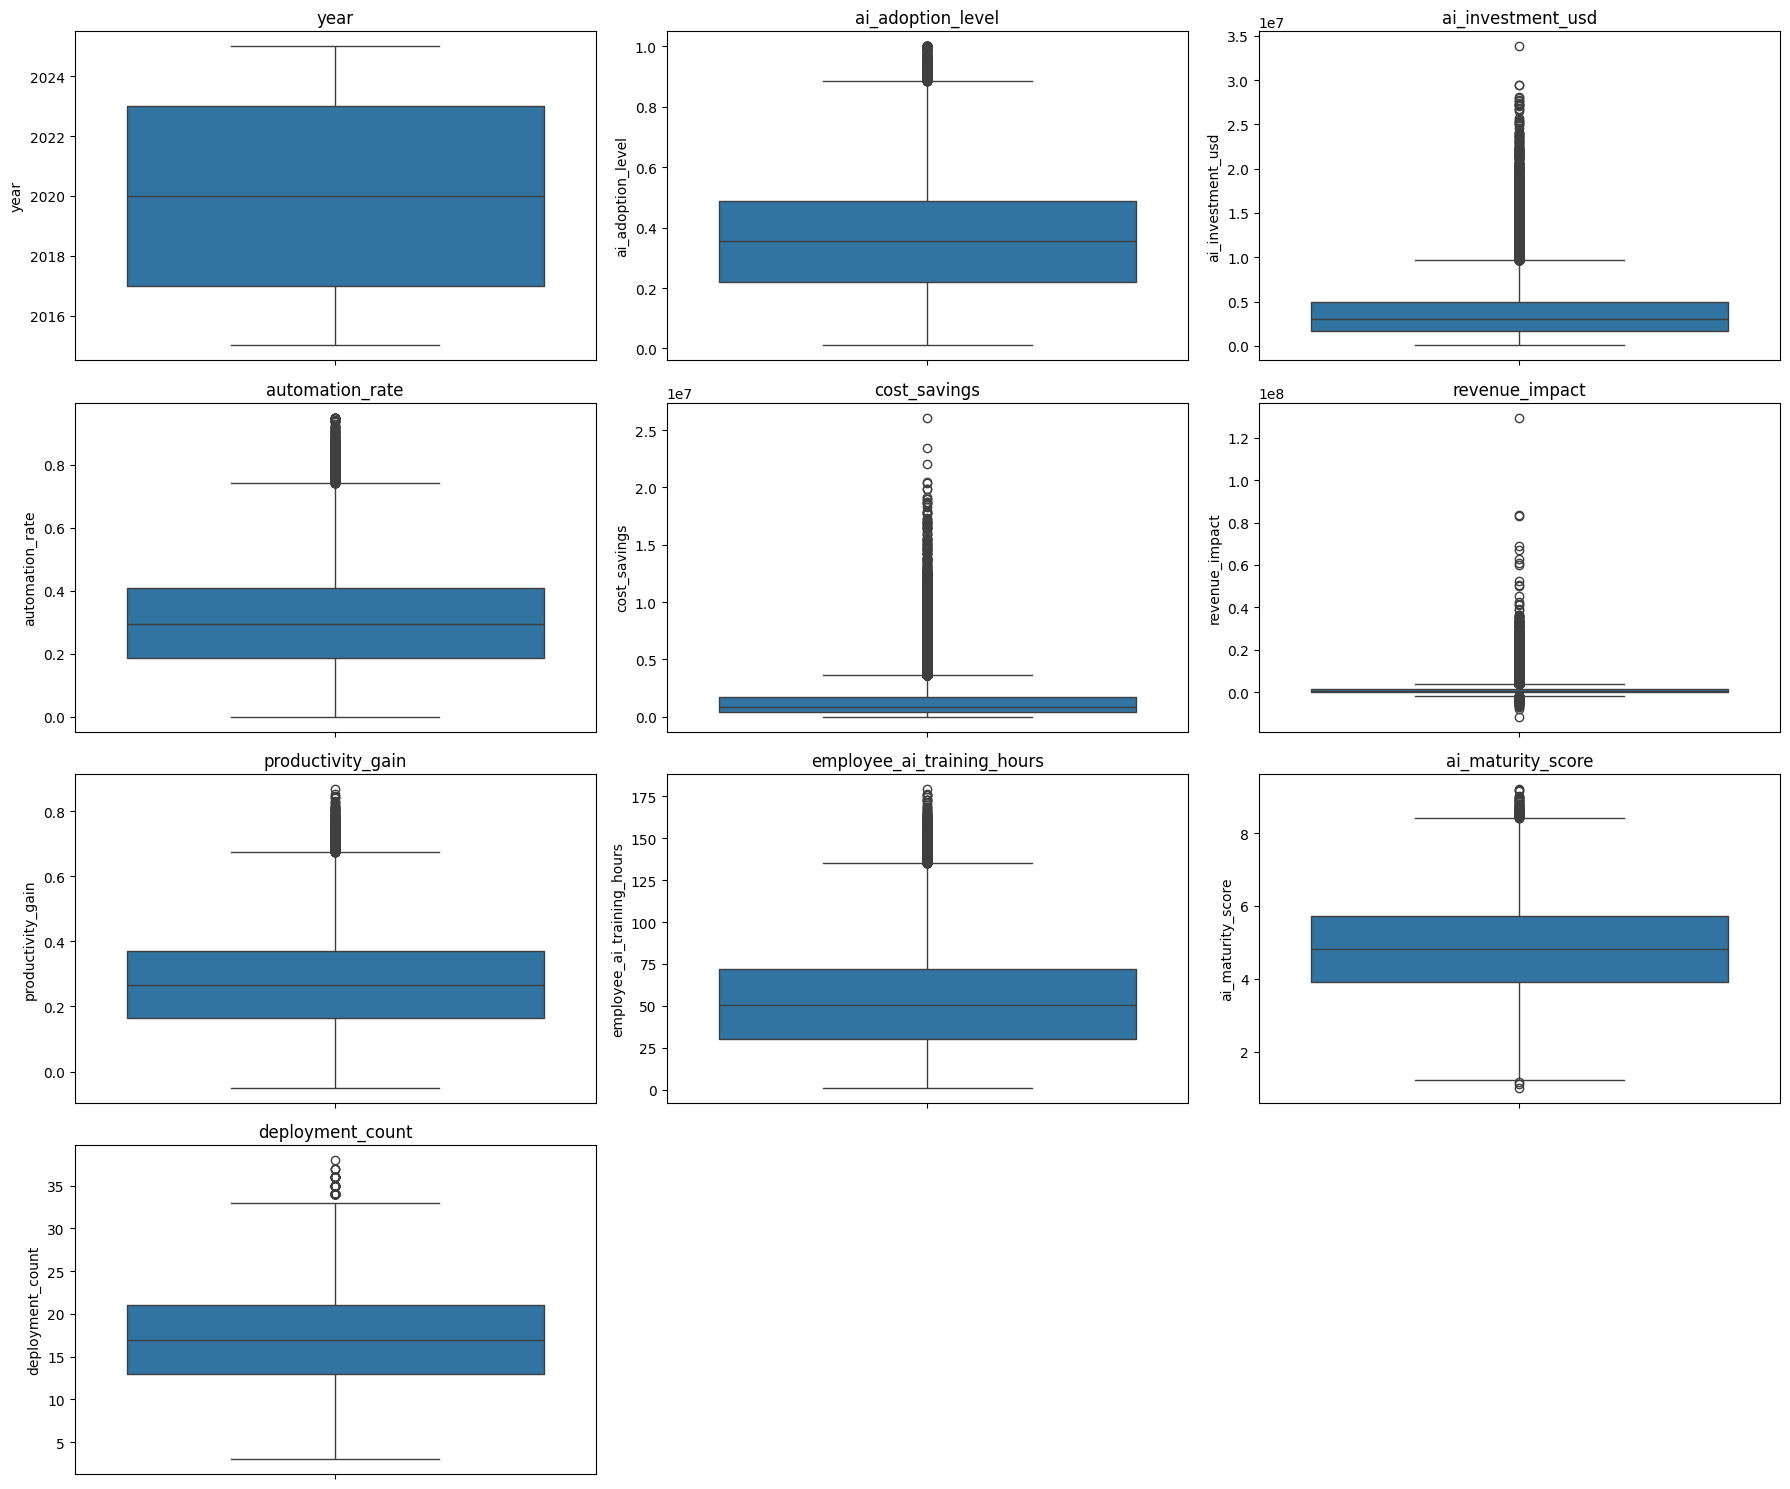

In [51]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18, 15))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

## Outlier Detection Using Z-Score

The Z-score method identifies observations that lie more than three standard deviations away from the mean. Such observations are considered potential outliers.

In [52]:
from scipy.stats import zscore

numeric_df = df.select_dtypes(include=['int64', 'float64'])

z_scores = numeric_df.apply(zscore)

outliers = (abs(z_scores) > 3).sum()

outliers

,0
year,0
ai_adoption_level,128
ai_investment_usd,1669
automation_rate,329
cost_savings,2149
revenue_impact,1797
productivity_gain,215
employee_ai_training_hours,296
ai_maturity_score,50
deployment_count,97


In [53]:
outlier_summary = pd.DataFrame({
    "Column": outliers.index,
    "Outliers": outliers.values
})

outlier_summary

,Column,Outliers
0,year,0
1,ai_adoption_level,128
2,ai_investment_usd,1669
3,automation_rate,329
4,cost_savings,2149
5,revenue_impact,1797
6,productivity_gain,215
7,employee_ai_training_hours,296
8,ai_maturity_score,50
9,deployment_count,97


### Observation

The Z-score analysis identified potential outliers in several numerical variables. The highest number of outliers was observed in **Cost Savings**, **Revenue Impact**, and **AI Investment (USD)**.

These observations are expected in a business dataset because organizations differ significantly in their AI investments and financial performance. Such values represent legitimate business variation rather than data quality issues.

Therefore, no outlier removal or transformation was performed, and all observations were retained for further analysis.

## Data Cleaning Summary

The dataset was examined for missing values, duplicate records, data type consistency, categorical value consistency, and potential outliers.

The following observations were made:

- No missing values were found.
- No duplicate records were identified.
- All columns had appropriate data types.
- Categorical variables contained consistent values without spelling inconsistencies.
- Outliers were detected in several numerical variables; however, they represent valid business observations and were retained for analysis.

Overall, the dataset was found to be clean and suitable for exploratory data analysis.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the relationships, patterns, and trends within the dataset. The analysis focuses on AI adoption, investment, productivity, revenue impact, automation, and other business performance metrics across industries, countries, and years.

---

## Business Question 1

### How has AI adoption changed from 2015 to 2025?

This analysis examines the trend of average AI adoption levels over time to understand whether organizations have increased their adoption of AI technologies during the study period.

In [54]:
# Calculate yearly average AI adoption level
yearly_ai = (
    df.groupby("year")["ai_adoption_level"]
      .mean()
      .reset_index()
)

yearly_ai

,year,ai_adoption_level
0,2015,0.191481
1,2016,0.220095
2,2017,0.252285
3,2018,0.287985
4,2019,0.320423
5,2020,0.353876
6,2021,0.390894
7,2022,0.426494
8,2023,0.455927
9,2024,0.494957


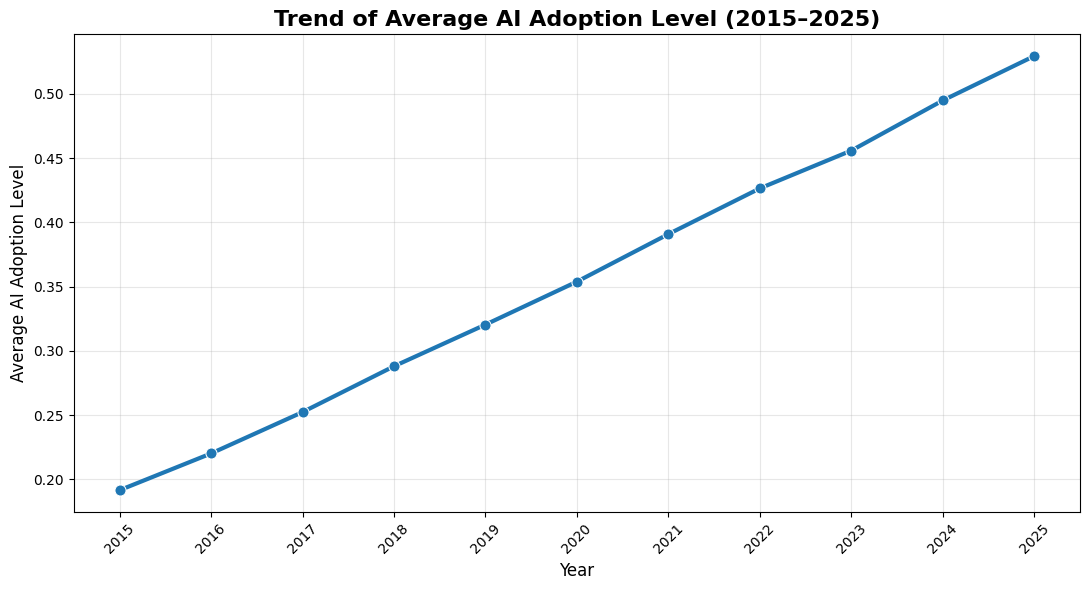

In [55]:
plt.figure(figsize=(11,6))

sns.lineplot(
    data=yearly_ai,
    x="year",
    y="ai_adoption_level",
    marker="o",
    linewidth=3,
    markersize=8,
    color="#1f77b4"
)

plt.title("Trend of Average AI Adoption Level (2015–2025)", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average AI Adoption Level", fontsize=12)
plt.xticks(yearly_ai["year"], rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The average AI adoption level shows a consistent upward trend from **2015 to 2025**. The average adoption level increased from approximately **0.19 in 2015** to **0.53 in 2025**, indicating a steady increase in AI implementation by organizations over the study period. No significant declines or fluctuations were observed, suggesting continuous growth in AI adoption.

### Business Insight

The steady increase in AI adoption suggests that organizations across industries have increasingly integrated AI technologies into their operations over the years. This trend highlights the growing strategic importance of AI in improving operational efficiency, innovation, and overall business performance. Organizations that continue investing in AI are likely to strengthen their competitive advantage in the future.

## Business Question 2

### Which industries have the highest average AI adoption level?

This analysis compares the average AI adoption level across different industries to identify the sectors that are leading in AI implementation.

In [56]:
# Calculate average AI adoption level by industry
industry_ai = (
    df.groupby("industry")["ai_adoption_level"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

industry_ai

,industry,ai_adoption_level
0,Agriculture,0.361970
1,Financial Services,0.357716
2,Technology,0.357612
3,Retail,0.357092
4,Logistics,0.356772
5,Manufacturing,0.355380
6,Education,0.355249
7,Healthcare,0.355150
8,Energy,0.355043
9,Telecom,0.354973


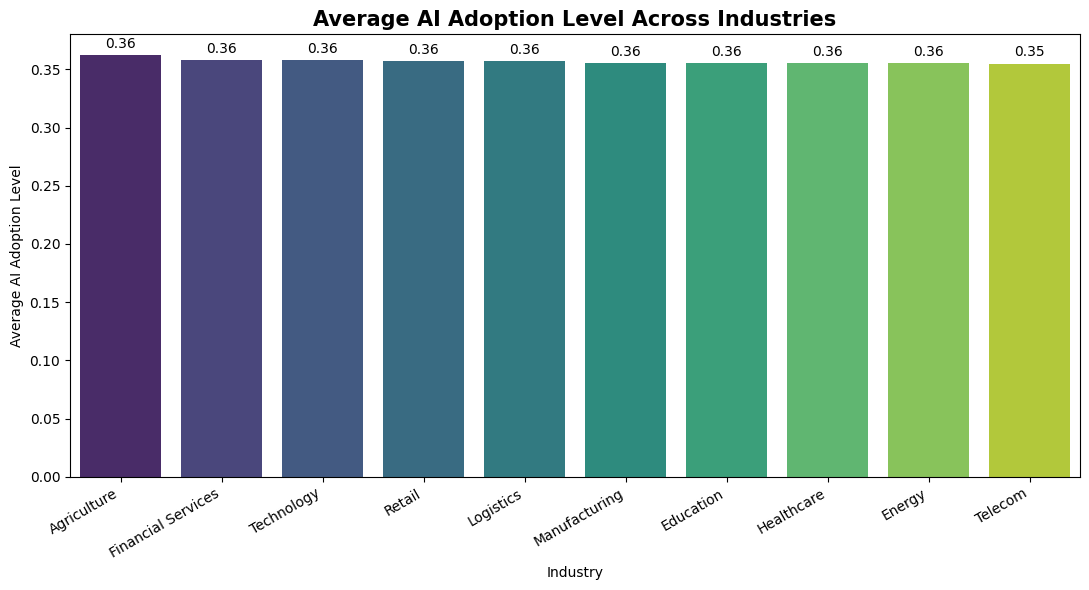

In [57]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=industry_ai,
    x="industry",
    y="ai_adoption_level",
    palette="viridis"
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Average AI Adoption Level Across Industries", fontsize=15, fontweight="bold")
plt.xlabel("Industry")
plt.ylabel("Average AI Adoption Level")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Observation

The average AI adoption level is remarkably consistent across all industries, with values ranging from approximately **0.35 to 0.36**. Agriculture, Financial Services, Technology, Retail, Logistics, Manufacturing, Education, Healthcare, and Energy exhibit nearly identical average adoption levels, while Telecom records a marginally lower value.

Overall, no industry demonstrates a significantly higher or lower level of AI adoption.

### Business Insight

The similar AI adoption levels across industries suggest that AI technologies are being adopted at a comparable pace regardless of the business sector. This indicates that AI is becoming a widely accepted business capability rather than being concentrated in a few specific industries. Organizations across different sectors appear to recognize the strategic value of AI for improving operational efficiency and business performance.

## Business Question 3

### Which industries invest the most in AI technologies?

This analysis compares the average AI investment across industries to identify which sectors allocate the highest financial resources toward AI adoption.

In [58]:
# Calculate average AI investment by industry
industry_investment = (
    df.groupby("industry")["ai_investment_usd"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

industry_investment

,industry,ai_investment_usd
0,Financial Services,6.190082e+06
1,Technology,4.924253e+06
2,Energy,4.295593e+06
3,Telecom,3.694194e+06
4,Healthcare,3.681292e+06
5,Manufacturing,3.066984e+06
6,Logistics,2.466763e+06
7,Retail,1.853833e+06
8,Agriculture,9.936259e+05
9,Education,6.126311e+05


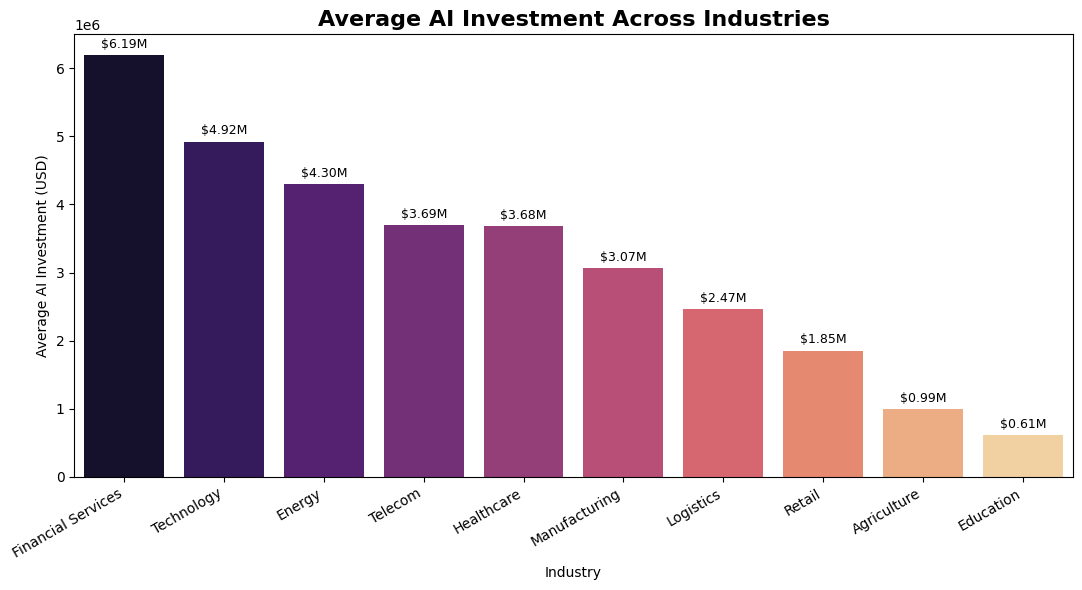

In [59]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=industry_investment,
    x="industry",
    y="ai_investment_usd",
    palette="magma"
)

# Add value labels
for container in ax.containers:
    labels = [f'${v.get_height()/1e6:.2f}M' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.title("Average AI Investment Across Industries", fontsize=16, fontweight="bold")
plt.xlabel("Industry")
plt.ylabel("Average AI Investment (USD)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Observation

The average AI investment varies significantly across industries.

- **Financial Services** records the highest average AI investment, exceeding **$6.19 million**.
- **Technology** follows with an average investment of approximately **$4.92 million**, while **Energy** ranks third with around **$4.30 million**.
- **Healthcare**, **Telecom**, and **Manufacturing** maintain moderate levels of AI investment.
- **Education** records the lowest average AI investment at approximately **$0.61 million**, followed by **Agriculture** and **Retail**.

These results indicate a substantial difference in AI investment strategies among industries.

### Business Insight

Industries with higher financial resources and greater dependence on technology, such as Financial Services and Technology, allocate significantly larger budgets toward AI initiatives. In contrast, sectors such as Education and Agriculture invest considerably less, possibly due to budget constraints, lower digital transformation priorities, or slower AI adoption.

Organizations operating in lower-investment sectors may benefit from increasing AI investments to improve operational efficiency, enhance decision-making, and remain competitive in an evolving digital economy.

### Key Finding

Financial Services is the leading investor in AI, while Education invests the least, highlighting substantial differences in AI investment priorities across industries.

## Business Question 4

### Does higher AI investment lead to higher productivity?

This analysis examines the relationship between AI investment and productivity gain to determine whether organizations investing more in AI experience greater improvements in productivity.

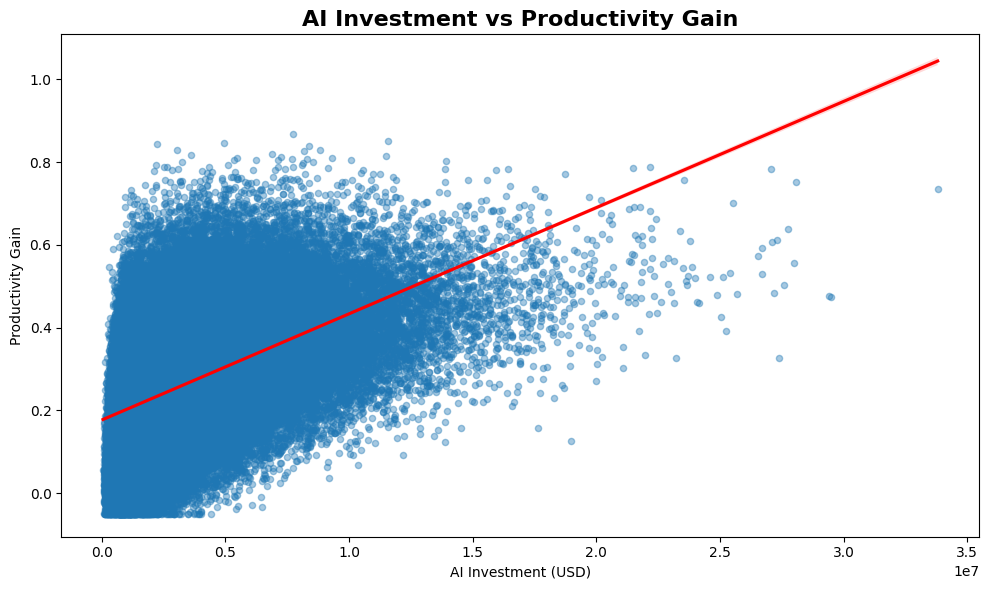

In [60]:
# Relationship between AI Investment and Productivity Gain

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="ai_investment_usd",
    y="productivity_gain",
    scatter_kws={"alpha":0.4, "s":20},
    line_kws={"color":"red"}
)

plt.title("AI Investment vs Productivity Gain", fontsize=16, fontweight="bold")
plt.xlabel("AI Investment (USD)")
plt.ylabel("Productivity Gain")

plt.tight_layout()
plt.show()

In [61]:
# Correlation between AI Investment and Productivity Gain
correlation = df["ai_investment_usd"].corr(df["productivity_gain"])

print(f"Correlation Coefficient: {correlation:.3f}")

Correlation Coefficient: 0.485


### Observation

The scatter plot and regression line indicate a **positive relationship** between AI investment and productivity gain. As AI investment increases, productivity gain generally tends to increase as well.

However, the data points are widely dispersed around the regression line, suggesting that the relationship is **moderate rather than strong**. This indicates that while AI investment contributes to productivity improvements, other organizational factors also influence productivity outcomes.

### Business Insight

Investing in AI has the potential to improve organizational productivity, but financial investment alone is not sufficient to maximize business performance. Organizations should complement AI investments with employee training, process optimization, and higher AI maturity to achieve greater productivity gains.

### Key Finding

Higher AI investment is generally associated with higher productivity, but the relationship is moderate, indicating that additional business factors influence productivity improvements.

## Business Question 5

### Which countries invest the most in AI technologies?

This analysis compares the average AI investment across different countries to identify the nations making the highest investments in AI technologies.

In [62]:
# Calculate average AI investment by country
country_investment = (
    df.groupby("country")["ai_investment_usd"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

country_investment

,country,ai_investment_usd
0,United States,4.635834e+06
1,Singapore,3.894496e+06
2,China,3.881207e+06
3,United Kingdom,3.643461e+06
4,Canada,3.604524e+06
5,Germany,3.545928e+06
6,Sweden,3.512487e+06
7,France,3.259512e+06
8,Japan,3.233951e+06
9,South Korea,3.227089e+06


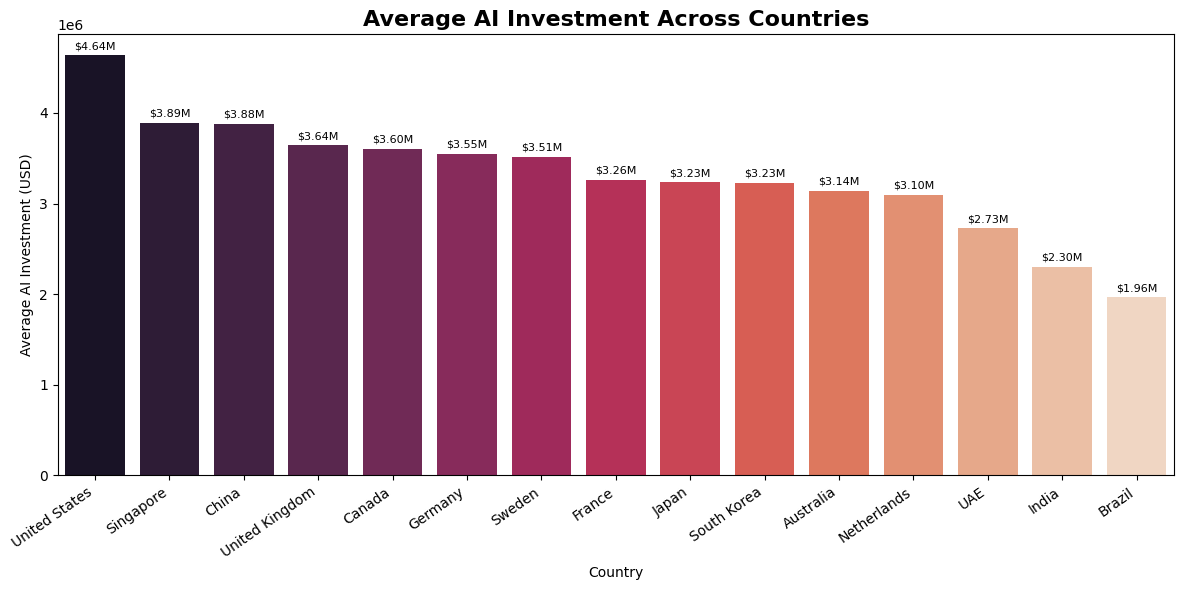

In [63]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=country_investment,
    x="country",
    y="ai_investment_usd",
    palette="rocket"
)

# Add value labels in millions
for container in ax.containers:
    labels = [f'${v.get_height()/1e6:.2f}M' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title("Average AI Investment Across Countries", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Average AI Investment (USD)")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

### Observation

The average AI investment differs noticeably across countries.

- The **United States** records the highest average AI investment at approximately **$4.64 million**.
- **Singapore** and **China** follow closely with average investments of approximately **$3.89 million** and **$3.88 million**, respectively.
- Countries such as the **United Kingdom**, **Canada**, **Germany**, and **Sweden** maintain moderate AI investment levels.
- **Brazil** records the lowest average AI investment at approximately **$1.96 million**, followed by **India** and the **UAE**.

These findings indicate considerable variation in AI investment strategies across countries.

### Business Insight

Countries with strong technological ecosystems and higher levels of digital transformation, such as the United States, Singapore, and China, demonstrate significantly greater AI investment. In contrast, countries with lower AI investment may have opportunities to accelerate digital transformation by increasing investments in AI infrastructure, research, and workforce development.

### Key Finding

The United States is the leading investor in AI among the analyzed countries, while Brazil records the lowest average AI investment, highlighting substantial differences in national AI investment priorities.

## Business Question 6

### Which industries achieve the highest revenue impact from AI adoption?

This analysis compares the average revenue impact across industries to identify which sectors benefit the most financially from AI adoption.

In [64]:
# Calculate average revenue impact by industry

industry_revenue = (
    df.groupby("industry")["revenue_impact"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

industry_revenue

,industry,revenue_impact
0,Technology,3.127946e+06
1,Financial Services,2.158522e+06
2,Telecom,1.255826e+06
3,Energy,1.231932e+06
4,Healthcare,1.138371e+06
5,Manufacturing,8.184863e+05
6,Logistics,7.567112e+05
7,Retail,7.179500e+05
8,Agriculture,2.510498e+05
9,Education,1.432985e+05


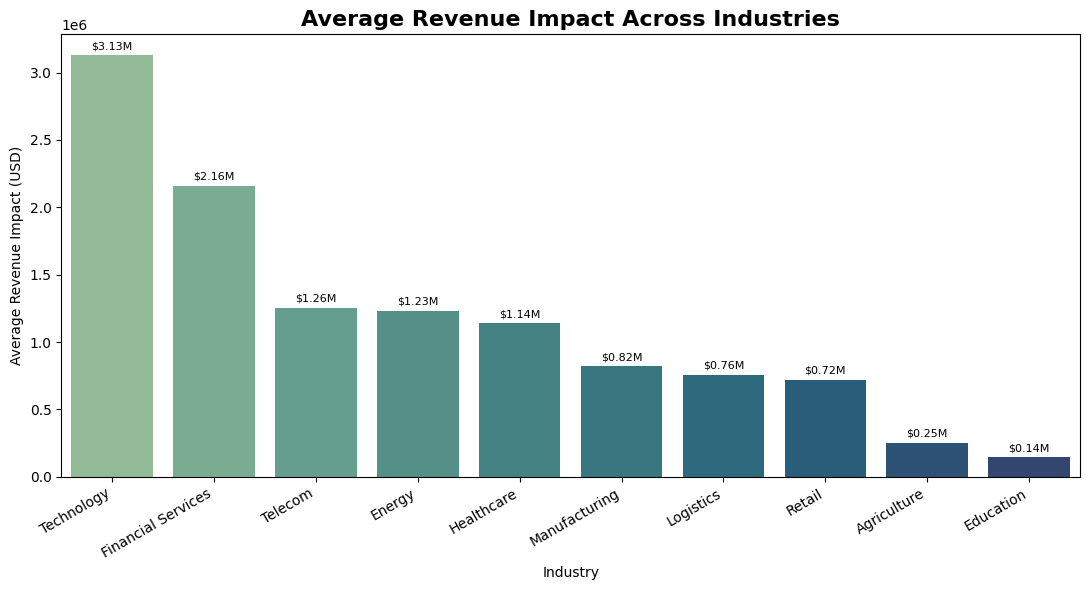

In [65]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=industry_revenue,
    x="industry",
    y="revenue_impact",
    palette="crest"
)

# Add value labels in millions
for container in ax.containers:
    labels = [f'${v.get_height()/1e6:.2f}M' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title("Average Revenue Impact Across Industries", fontsize=16, fontweight="bold")
plt.xlabel("Industry")
plt.ylabel("Average Revenue Impact (USD)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Observation

The average revenue impact generated through AI adoption varies significantly across industries.

- **Technology** records the highest average revenue impact at approximately **$3.13 million**.
- **Financial Services** ranks second with an average revenue impact of approximately **$2.16 million**.
- **Telecom**, **Energy**, and **Healthcare** generate moderate revenue gains from AI adoption.
- **Education** records the lowest average revenue impact at approximately **$0.14 million**, followed by **Agriculture**.

These findings suggest that industries adopting AI at a larger scale tend to realize greater financial returns.

### Business Insight

Industries that rely heavily on digital technologies and data-driven operations, such as Technology and Financial Services, derive the greatest financial benefits from AI adoption. Their higher revenue impact indicates that AI can significantly improve customer experiences, automate complex processes, and create new revenue opportunities.

Industries with lower revenue impact may benefit from expanding AI implementation to improve operational efficiency and unlock additional business value.

### Key Finding

Technology generates the highest revenue impact from AI adoption, while Education records the lowest, demonstrating that the financial returns of AI differ considerably across industries.

## Business Question 7

### Does AI maturity lead to higher revenue impact?

This analysis examines the relationship between an organization's AI maturity score and the revenue impact generated through AI adoption. The objective is to determine whether organizations with higher AI maturity tend to achieve greater financial returns.

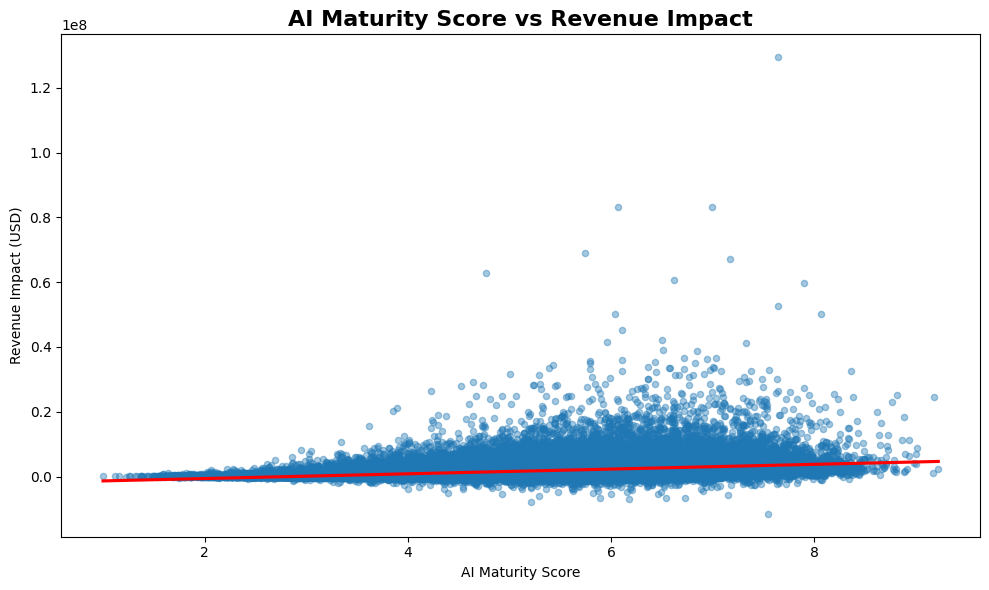

In [66]:
# Relationship between AI Maturity Score and Revenue Impact

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="ai_maturity_score",
    y="revenue_impact",
    scatter_kws={"alpha":0.4, "s":20},
    line_kws={"color":"red"}
)

plt.title("AI Maturity Score vs Revenue Impact", fontsize=16, fontweight="bold")
plt.xlabel("AI Maturity Score")
plt.ylabel("Revenue Impact (USD)")

plt.tight_layout()
plt.show()

In [67]:
# Correlation between AI Maturity Score and Revenue Impact

correlation = df["ai_maturity_score"].corr(df["revenue_impact"])

print(f"Correlation Coefficient: {correlation:.3f}")

Correlation Coefficient: 0.382


### Observation

The scatter plot and correlation analysis indicate a **weak to moderate positive relationship** between AI maturity score and revenue impact.

The Pearson correlation coefficient is **0.382**, suggesting that organizations with higher AI maturity generally tend to generate higher revenue impact. However, the relationship is not particularly strong, as considerable variation exists among organizations with similar AI maturity scores.

This indicates that while AI maturity contributes to revenue growth, other business factors also play an important role in determining financial performance.

### Business Insight

Developing AI maturity can contribute to improved financial performance by enabling organizations to use AI more effectively across business operations. However, AI maturity alone is not sufficient to maximize revenue. Organizations should combine mature AI capabilities with strategic investments, employee training, process optimization, and effective implementation practices to achieve greater business value.

### Key Finding

AI maturity shows a **weak to moderate positive correlation (r = 0.382)** with revenue impact, indicating that organizations with higher AI maturity generally achieve better financial outcomes, although additional factors also influence revenue growth.

## Business Question 8

### Does employee AI training improve AI maturity?

This analysis examines the relationship between employee AI training hours and AI maturity score to determine whether organizations that invest more in employee training tend to achieve higher AI maturity.

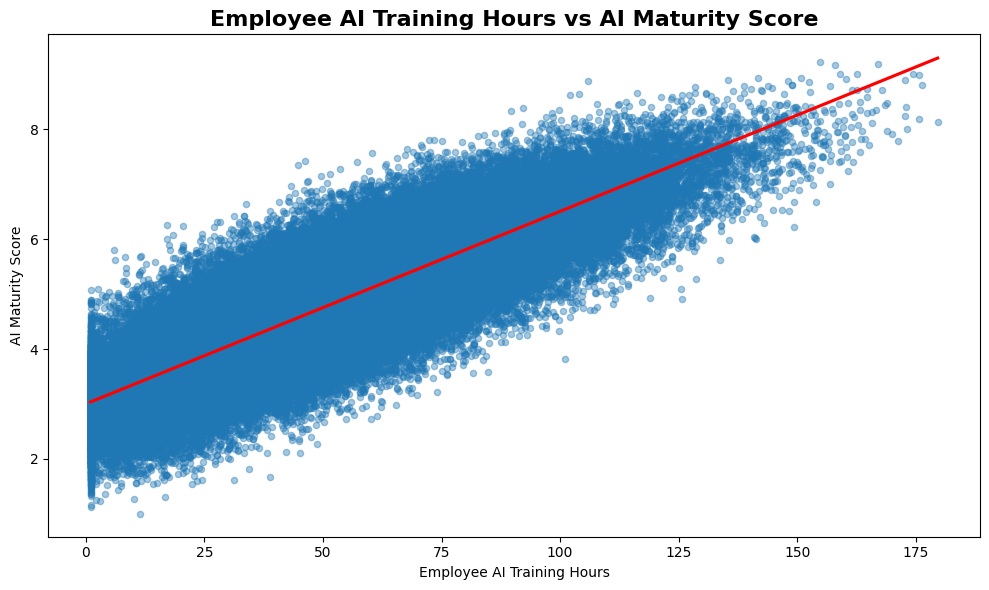

In [68]:
# Relationship between Employee AI Training Hours and AI Maturity Score

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="employee_ai_training_hours",
    y="ai_maturity_score",
    scatter_kws={"alpha":0.4, "s":20},
    line_kws={"color":"red"}
)

plt.title("Employee AI Training Hours vs AI Maturity Score",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Employee AI Training Hours")
plt.ylabel("AI Maturity Score")

plt.tight_layout()
plt.show()

In [69]:
# Correlation between Employee AI Training Hours and AI Maturity Score

correlation = df["employee_ai_training_hours"].corr(df["ai_maturity_score"])

print(f"Correlation Coefficient: {correlation:.3f}")

Correlation Coefficient: 0.845


### Observation

The scatter plot and correlation analysis reveal a **very strong positive relationship** between employee AI training hours and AI maturity score.

The Pearson correlation coefficient is **0.845**, indicating that organizations providing more AI training to employees generally achieve significantly higher AI maturity scores. The data points closely follow the upward regression line, showing a consistent positive trend with relatively low dispersion.

This suggests that employee training is strongly associated with the successful development and implementation of AI capabilities within organizations.

### Business Insight

Employee training plays a critical role in building organizational AI maturity. Organizations that invest in developing AI-related skills among their workforce are better positioned to adopt, manage, and scale AI technologies effectively. Continuous learning and workforce development should therefore be considered strategic investments that support long-term AI success.

### Key Finding

Employee AI training has a **very strong positive correlation (r = 0.845)** with AI maturity, making workforce development one of the most influential factors in achieving successful AI adoption.

## Business Question 9

### Which industries achieve the highest productivity gains through AI adoption?

This analysis compares the average productivity gain across industries to identify which sectors benefit the most in terms of operational efficiency after adopting AI technologies.

In [70]:
# Calculate average productivity gain by industry

industry_productivity = (
    df.groupby("industry")["productivity_gain"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

industry_productivity

,industry,productivity_gain
0,Manufacturing,0.302521
1,Logistics,0.297242
2,Energy,0.289118
3,Agriculture,0.280533
4,Financial Services,0.279261
5,Technology,0.265294
6,Telecom,0.263685
7,Retail,0.252050
8,Healthcare,0.238494
9,Education,0.211951


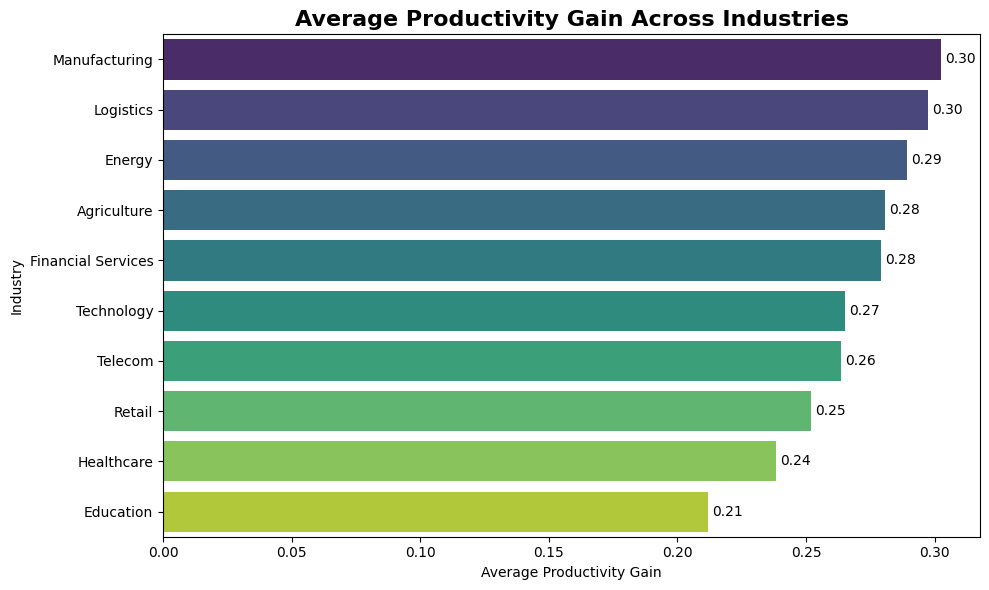

In [71]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=industry_productivity,
    y="industry",
    x="productivity_gain",
    palette="viridis"
)

# Add value labels
for container in ax.containers:
    labels = [f'{v.get_width():.2f}' for v in container]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Average Productivity Gain Across Industries",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Average Productivity Gain")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

### Observation

The average productivity gain varies across industries, although the differences are relatively moderate.

- **Manufacturing** and **Logistics** achieve the highest average productivity gain at approximately **0.30**.
- **Energy** follows closely with an average productivity gain of **0.29**.
- **Agriculture** and **Financial Services** record productivity gains of approximately **0.28**.
- **Education** has the lowest average productivity gain at approximately **0.21**, followed by **Healthcare** at **0.24**.

These results indicate that the operational benefits of AI adoption differ across industries.

### Business Insight

Industries such as Manufacturing and Logistics benefit significantly from AI-driven automation and process optimization, leading to higher productivity gains. In contrast, sectors like Education and Healthcare may require more specialized AI applications, regulatory compliance, or human involvement, which can limit immediate productivity improvements. Organizations in these sectors should focus on identifying AI use cases that complement human expertise rather than replacing it.

### Key Finding

Manufacturing and Logistics achieve the highest productivity gains from AI adoption, while Education records the lowest average productivity improvement among the analyzed industries.

## Business Question 10

### Which industries achieve the highest cost savings through AI adoption?

This analysis compares the average cost savings across industries to identify which sectors benefit the most financially from AI-driven operational efficiencies.

In [72]:
# Calculate average cost savings by industry

industry_cost = (
    df.groupby("industry")["cost_savings"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

industry_cost

,industry,cost_savings
0,Technology,2.524308e+06
1,Financial Services,2.071605e+06
2,Energy,1.265016e+06
3,Telecom,1.184715e+06
4,Healthcare,9.781845e+05
5,Manufacturing,8.787065e+05
6,Logistics,7.894353e+05
7,Retail,6.305766e+05
8,Agriculture,2.504069e+05
9,Education,1.146612e+05


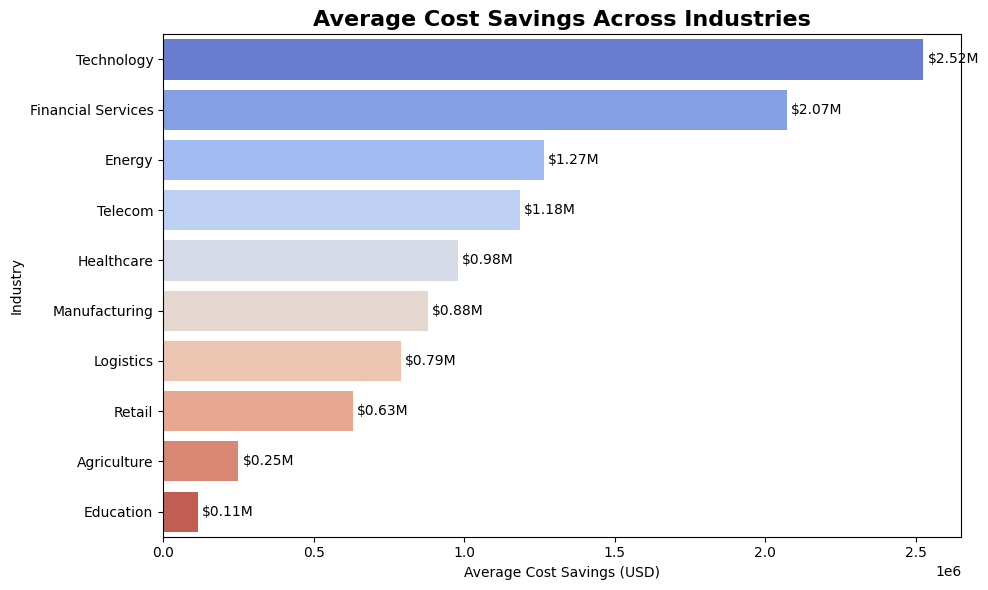

In [73]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=industry_cost,
    y="industry",
    x="cost_savings",
    palette="coolwarm"
)

# Add labels in millions
for container in ax.containers:
    labels = [f'${v.get_width()/1e6:.2f}M' for v in container]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Average Cost Savings Across Industries",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Average Cost Savings (USD)")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

### Observation

The average cost savings achieved through AI adoption vary considerably across industries.

- **Technology** records the highest average cost savings at approximately **$2.52 million**.
- **Financial Services** ranks second with approximately **$2.07 million** in average cost savings.
- **Energy** and **Telecom** also achieve substantial cost savings, exceeding **$1 million**.
- **Healthcare**, **Manufacturing**, **Logistics**, and **Retail** generate moderate cost savings.
- **Education** records the lowest average cost savings at approximately **$0.11 million**, followed by **Agriculture**.

These findings indicate that AI-driven cost optimization differs significantly across industries.

### Business Insight

Technology and Financial Services realize the greatest cost savings from AI adoption due to their extensive use of automation, intelligent decision-making systems, and data-driven operations. Industries such as Education and Agriculture experience comparatively lower savings, suggesting that AI applications in these sectors are either less mature or less automation-intensive. Expanding AI use cases in these industries may unlock additional operational efficiencies and reduce long-term costs.

### Key Finding

Technology achieves the highest average cost savings from AI adoption, while Education records the lowest, demonstrating that the financial efficiency gains from AI vary substantially across industries.

## Business Question 11

### Which factors are most strongly related to AI adoption and business performance?

This analysis uses a correlation heatmap to examine the relationships among numerical variables in the dataset. Correlation analysis helps identify variables that move together, enabling a better understanding of the factors influencing AI adoption and business performance.

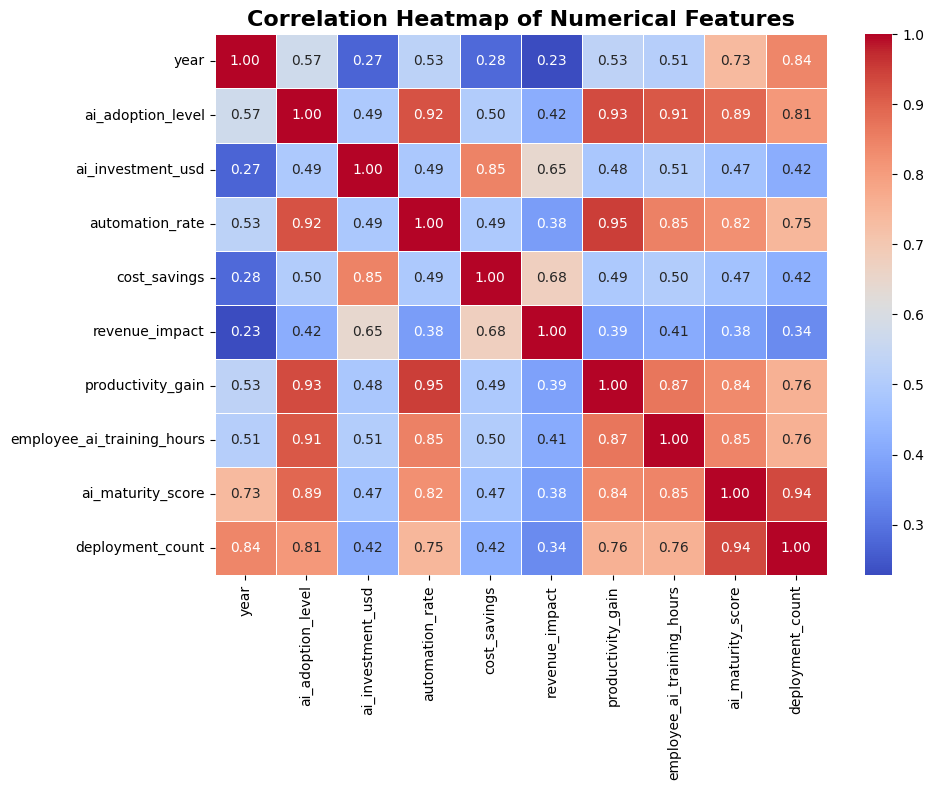

In [74]:
# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap reveals several strong positive relationships among the numerical variables.

- **Automation Rate** and **Productivity Gain** have a very strong positive correlation (**0.95**), indicating that higher automation is strongly associated with increased productivity.
- **AI Maturity Score** and **Deployment Count** also exhibit a very strong positive correlation (**0.94**), suggesting that organizations with higher AI maturity tend to deploy more AI solutions.
- **AI Adoption Level** is strongly correlated with **Productivity Gain (0.93)**, **Automation Rate (0.92)**, and **Employee AI Training Hours (0.91)**.
- **Employee AI Training Hours** show a strong positive relationship with **AI Maturity Score (0.85)** and **Productivity Gain (0.87)**.
- **AI Investment** has a strong correlation with **Cost Savings (0.85)** and a moderate correlation with **Revenue Impact (0.65)**.
- No significant negative correlations are observed, indicating that improvements in one AI-related metric generally coincide with improvements in other business performance metrics.

### Business Insight

The correlation analysis demonstrates that successful AI adoption depends on multiple interconnected factors rather than a single investment. Organizations that invest in employee training, increase automation, and improve AI maturity tend to achieve higher productivity, greater deployment of AI solutions, and better financial outcomes. This suggests that AI success should be viewed as a holistic transformation involving technology, workforce development, and operational improvements.

### Key Finding

The strongest relationships are observed between **Automation Rate and Productivity Gain (0.95)** and between **AI Maturity Score and Deployment Count (0.94)**, highlighting automation and organizational AI maturity as key drivers of business performance.

## Business Question 12

### What are the relationships among the key business performance variables?

A pair plot is used to visualize pairwise relationships among the most important numerical variables in the dataset. It helps identify trends, distributions, correlations, and potential patterns that may not be visible through individual charts.

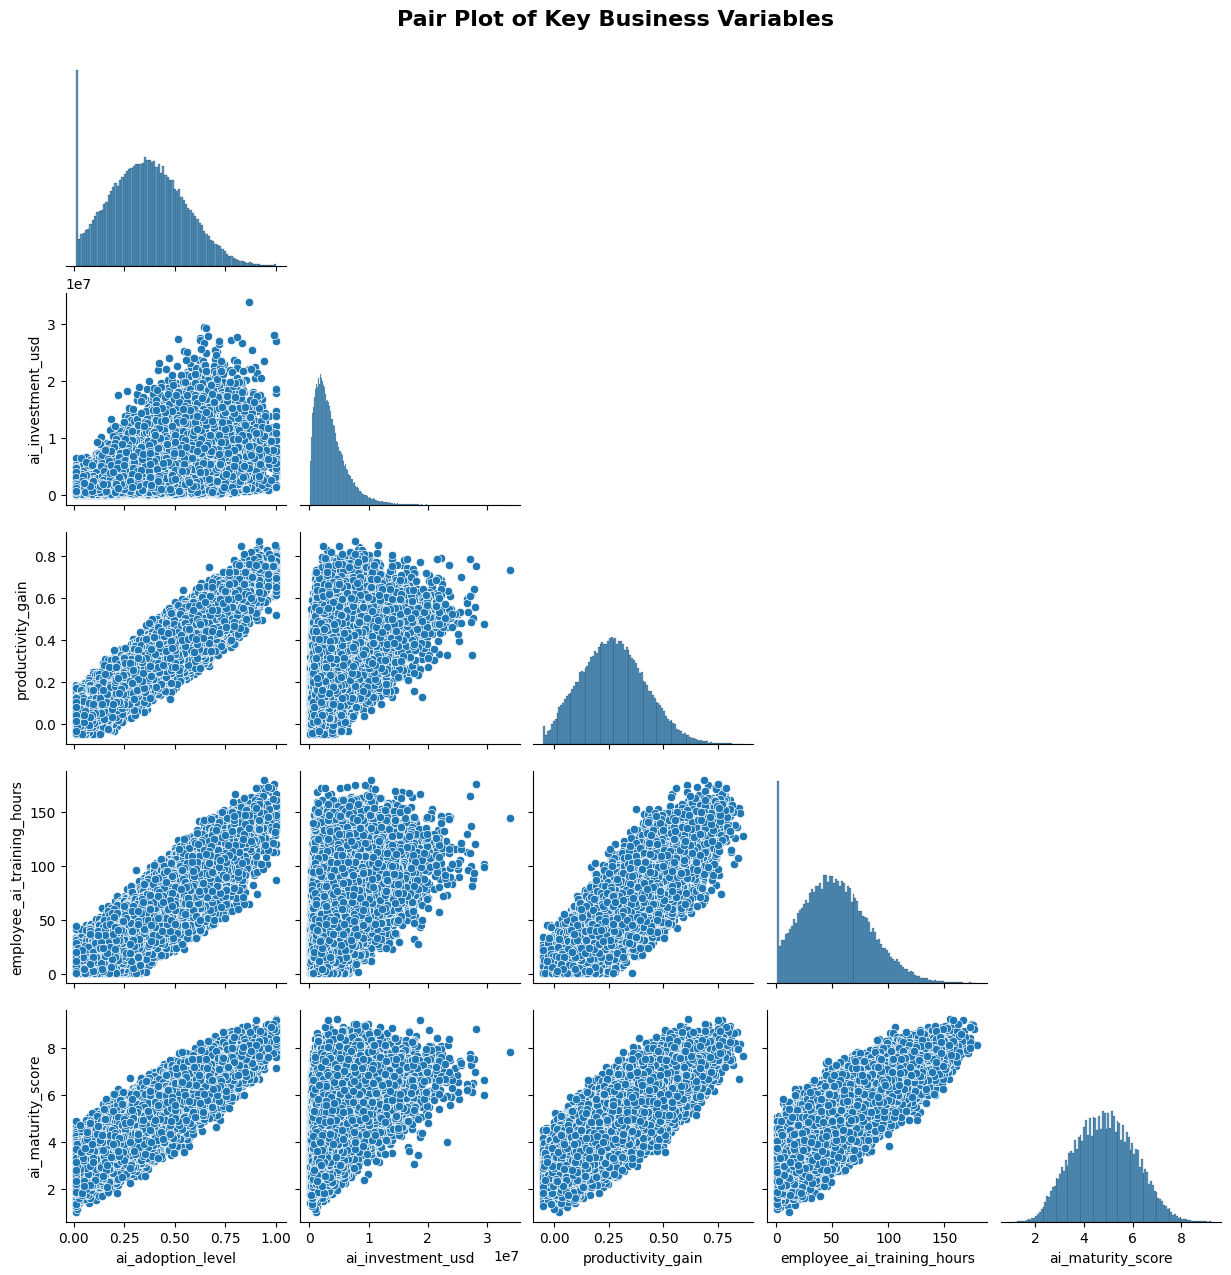

In [75]:
# Select important numerical features
pairplot_df = df[[
    "ai_adoption_level",
    "ai_investment_usd",
    "productivity_gain",
    "employee_ai_training_hours",
    "ai_maturity_score"
]]

sns.pairplot(
    pairplot_df,
    corner=True,
    diag_kind="hist"
)

plt.suptitle(
    "Pair Plot of Key Business Variables",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)

plt.show()

### Observation

The pair plot provides a comprehensive visualization of the relationships among the selected business variables.

- **Employee AI Training Hours** and **AI Maturity Score** exhibit a strong positive linear relationship, confirming that organizations investing more in employee training generally achieve higher AI maturity.
- **AI Adoption Level** shows a strong positive relationship with both **Productivity Gain** and **AI Maturity Score**, indicating that increased AI adoption contributes to better organizational performance.
- **AI Investment** displays a positive relationship with the selected variables, although the relationship is more dispersed compared to the other feature pairs.
- The diagonal histograms indicate that most variables follow approximately unimodal distributions with varying degrees of skewness, particularly AI Investment, which is positively skewed due to a small number of organizations making substantially larger investments.

### Business Insight

The pair plot demonstrates that AI adoption, employee training, productivity, and AI maturity are closely interconnected. Organizations that simultaneously invest in workforce development and AI implementation tend to achieve greater productivity improvements and higher AI maturity. These findings suggest that successful AI transformation requires coordinated investments in both technology and human capital rather than focusing solely on financial investment.

### Key Finding

The strongest visual relationships are observed between **Employee AI Training Hours and AI Maturity Score** and between **AI Adoption Level and Productivity Gain**, reinforcing that employee capability development and effective AI adoption are key drivers of business performance.

# Key Business Insights

Based on the exploratory data analysis, the following key insights were identified regarding AI adoption and its impact on business performance.

1. AI adoption has increased consistently from **2015 to 2025**, indicating continuous growth in the adoption of AI technologies across organizations.

2. AI adoption levels are relatively similar across industries, suggesting that AI has become a common strategic initiative rather than being limited to specific sectors.

3. Financial Services and Technology industries invest significantly more in AI than other industries, demonstrating a stronger focus on digital transformation.

4. The United States records the highest average AI investment among all countries, while Brazil and India have comparatively lower investment levels.

5. Technology generates the highest revenue impact and cost savings from AI adoption, indicating that AI delivers substantial financial benefits in technology-driven industries.

6. Manufacturing and Logistics achieve the highest productivity gains, highlighting the effectiveness of AI-powered automation in operational environments.

7. AI investment shows a positive relationship with productivity gain, indicating that organizations investing more in AI generally experience higher productivity improvements.

8. Employee AI training exhibits a **very strong positive correlation (r = 0.845)** with AI maturity, making workforce development one of the strongest contributors to successful AI adoption.

9. AI maturity demonstrates a positive relationship with revenue impact, suggesting that organizations with mature AI capabilities generally achieve better financial performance.

10. Correlation analysis reveals that automation rate, employee training, AI maturity, and productivity are strongly interconnected, emphasizing that successful AI adoption requires a combination of technology, skilled employees, and operational transformation.

# Business Recommendations

The following recommendations are based on the insights obtained from the exploratory data analysis.

1. Increase investment in employee AI training programs, as workforce development has the strongest relationship with AI maturity.

2. Focus on improving AI maturity by integrating AI into business processes rather than limiting adoption to isolated projects.

3. Expand AI-driven automation initiatives to improve organizational productivity and operational efficiency.

4. Organizations in lower-performing industries, such as Education and Agriculture, should identify additional AI use cases to improve revenue generation and reduce operational costs.

5. Allocate AI investments strategically by prioritizing projects that provide measurable business value rather than increasing spending without clear objectives.

6. Continuously monitor AI performance using key business metrics such as productivity gain, revenue impact, cost savings, and AI maturity score.

7. Encourage cross-functional collaboration between business teams, technical teams, and employees to maximize the effectiveness of AI initiatives.

8. Develop long-term AI adoption strategies that combine technology investment, workforce development, automation, and continuous performance evaluation.

# Conclusion

This project analyzed AI adoption and its impact on business performance using data from multiple industries and countries between **2015 and 2025**. The analysis included data cleaning, exploratory data analysis, correlation analysis, and visualization to identify meaningful business trends and relationships.

The results indicate that AI adoption has grown steadily over time and positively influences productivity, revenue generation, and operational efficiency. Industries such as Technology and Financial Services demonstrate the highest AI investment and financial returns, while Manufacturing and Logistics achieve the greatest productivity improvements. Employee AI training was identified as one of the strongest contributors to AI maturity, emphasizing the importance of workforce development in successful AI implementation.

Overall, the findings suggest that organizations can maximize the value of AI by combining strategic investment, employee training, automation, and continuous improvement of AI capabilities. A balanced approach toward technology and human capital is essential for achieving sustainable business growth through AI.